#Food Waste Forecasting — CC26-PSU403
**Coding Camp 2026 powered by DBS Foundation**

Model Deep Learning untuk memprediksi **stok optimal** makanan berdasarkan kondisi event.

---

## STEP 1 — Install & Import Library

In [1]:
!pip install tensorflow scikit-learn pandas numpy matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pickle
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

## STEP 2 — Load Dataset

In [2]:
from google.colab import files
files.upload()

Saving food_wastage_cleaned.csv to food_wastage_cleaned.csv


{'food_wastage_cleaned.csv': b'Type of Food,Number of Guests,Event Type,Quantity of Food,Storage Conditions,Seasonality,Preparation Method,Wastage Food Amount\nMeat,310,Corporate,450,Refrigerated,All Seasons,Buffet,25\nMeat,400,Birthday,500,Room Temperature,Winter,Buffet,40\nVegetables,302,Birthday,371,Refrigerated,Summer,Buffet,27\nMeat,491,Birthday,497,Refrigerated,All Seasons,Finger Food,32\nMeat,300,Corporate,400,Refrigerated,Winter,Finger Food,25\nMeat,302,Birthday,371,Refrigerated,Summer,Buffet,27\nMeat,240,Wedding,450,Refrigerated,Winter,Sit-down Dinner,20\nMeat,300,Wedding,400,Refrigerated,Summer,Finger Food,25\nFruits,320,Corporate,400,Refrigerated,All Seasons,Buffet,45\nMeat,400,Corporate,500,Refrigerated,Winter,Finger Food,40\nFruits,320,Wedding,400,Room Temperature,Summer,Buffet,35\nMeat,302,Birthday,371,Room Temperature,Winter,Buffet,27\nMeat,400,Wedding,500,Refrigerated,Summer,Sit-down Dinner,25\nMeat,250,Social Gathering,350,Room Temperature,Winter,Buffet,10\nFruits,267,

In [3]:
df = pd.read_csv('food_wastage_cleaned.csv')

print('Shape:', df.shape)
print('\n5 Data Pertama:')
display(df.head())

print('\nMissing Values:')
print(df.isnull().sum())

print('\nStatistik Numerik:')
display(df.describe())

Shape: (1782, 8)

5 Data Pertama:


,Type of Food,Number of Guests,Event Type,Quantity of Food,Storage Conditions,Seasonality,Preparation Method,Wastage Food Amount
0,Meat,310,Corporate,450,Refrigerated,All Seasons,Buffet,25
1,Meat,400,Birthday,500,Room Temperature,Winter,Buffet,40
2,Vegetables,302,Birthday,371,Refrigerated,Summer,Buffet,27
3,Meat,491,Birthday,497,Refrigerated,All Seasons,Finger Food,32
4,Meat,300,Corporate,400,Refrigerated,Winter,Finger Food,25



Missing Values:
Type of Food           0
Number of Guests       0
Event Type             0
Quantity of Food       0
Storage Conditions     0
Seasonality            0
Preparation Method     0
Wastage Food Amount    0
dtype: int64

Statistik Numerik:


,Number of Guests,Quantity of Food,Wastage Food Amount
count,1782.000000,1782.000000,1782.000000
mean,317.804714,411.125701,28.536476
std,67.829658,65.204674,10.461317
min,207.000000,280.000000,10.000000
25%,267.000000,350.000000,20.000000
50%,302.000000,400.000000,26.500000
75%,350.000000,480.000000,35.000000
max,491.000000,500.000000,63.000000


## STEP 3 — Preprocessing: Encoding Kategorikal
ubah kolom teks jadi angka menggunakan supaya bisa diproses model.

In [4]:
categorical_cols = [
    'Type of Food',
    'Event Type',
    'Storage Conditions',
    'Seasonality',
    'Preparation Method'
]

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

display(df.head())

Type of Food: {'Baked Goods': np.int64(0), 'Dairy Products': np.int64(1), 'Fruits': np.int64(2), 'Meat': np.int64(3), 'Vegetables': np.int64(4)}
Event Type: {'Birthday': np.int64(0), 'Corporate': np.int64(1), 'Social Gathering': np.int64(2), 'Wedding': np.int64(3)}
Storage Conditions: {'Refrigerated': np.int64(0), 'Room Temperature': np.int64(1)}
Seasonality: {'All Seasons': np.int64(0), 'Summer': np.int64(1), 'Winter': np.int64(2)}
Preparation Method: {'Buffet': np.int64(0), 'Finger Food': np.int64(1), 'Sit-down Dinner': np.int64(2)}


,Type of Food,Number of Guests,Event Type,Quantity of Food,Storage Conditions,Seasonality,Preparation Method,Wastage Food Amount
0,3,310,1,450,0,0,0,25
1,3,400,0,500,1,2,0,40
2,4,302,0,371,0,1,0,27
3,3,491,0,497,0,0,1,32
4,3,300,1,400,0,2,1,25


## STEP 4 — Split Input (X) dan Output (y) + Normalisasi

- **Input (X):** semua kolom kecuali `Quantity of Food`
- **Output (y):** `Quantity of Food` — stok optimal yang mau diprediksi
- **Normalisasi:** MinMaxScaler biar semua nilai ada di rentang 0–1

In [5]:
X = df.drop(columns=['Quantity of Food'])
y = df['Quantity of Food']

print('Fitur Input (X):', X.columns.tolist())
print('Target Output (y): Quantity of Food')
print(f'Range y: {y.min()} - {y.max()} porsi, rata-rata: {y.mean():.1f} porsi')

# Normalisasi
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split 80%/20%
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f'\nTrain: {X_train.shape} | Test: {X_test.shape}')

Fitur Input (X): ['Type of Food', 'Number of Guests', 'Event Type', 'Storage Conditions', 'Seasonality', 'Preparation Method', 'Wastage Food Amount']
Target Output (y): Quantity of Food
Range y: 280 - 500 porsi, rata-rata: 411.1 porsi

Train: (1425, 7) | Test: (357, 7)


## STEP 5 — Custom Components (Layer, Loss, Callback)

Memenuhi syarat MVP Capstone: minimal ada 1 komponen custom. Di sini kita membuat 3 sekaligus:
- `ResidualDenseBlock`: Custom Layer
- `HuberMAELoss`: Custom Loss
- `EarlyStoppingWithRestore`: Custom Callback

In [6]:
@keras.utils.register_keras_serializable(package="FoodWaste")
class ResidualDenseBlock(keras.layers.Layer):
    def __init__(self, units, dropout_rate=0.3, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.dropout_rate = dropout_rate

    def build(self, input_shape):
        input_dim = input_shape[-1]
        self.dense1 = keras.layers.Dense(self.units, kernel_initializer='he_normal')
        self.bn1 = keras.layers.BatchNormalization()
        self.dense2 = keras.layers.Dense(input_dim, kernel_initializer='he_normal')
        self.bn2 = keras.layers.BatchNormalization()
        self.dropout = keras.layers.Dropout(self.dropout_rate)

    def call(self, inputs, training=False):
        x = self.dense1(inputs)
        x = self.bn1(x, training=training)
        x = tf.nn.relu(x)
        x = self.dropout(x, training=training)
        x = self.dense2(x)
        x = self.bn2(x, training=training)
        return tf.nn.relu(x + inputs)

    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units, 'dropout_rate': self.dropout_rate})
        return config

@keras.utils.register_keras_serializable(package="FoodWaste")
class HuberMAELoss(keras.losses.Loss):
    def __init__(self, delta=1.0, alpha=0.7, **kwargs):
        super().__init__(**kwargs)
        self.delta = delta
        self.alpha = alpha

    def call(self, y_true, y_pred):
        huber = tf.keras.losses.huber(y_true, y_pred, delta=self.delta)
        mae = tf.reduce_mean(tf.abs(y_true - y_pred))
        return self.alpha * huber + (1.0 - self.alpha) * mae

    def get_config(self):
        config = super().get_config()
        config.update({'delta': self.delta, 'alpha': self.alpha})
        return config

class EarlyStoppingWithRestore(keras.callbacks.Callback):
    def __init__(self, patience=20, min_delta=1e-4, verbose=1):
        super().__init__()
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.wait = 0
        self.best_loss = np.inf
        self.best_weights = None

    def on_train_begin(self, logs=None):
        self.wait = 0
        self.best_loss = np.inf

    def on_epoch_end(self, epoch, logs=None):
        current_loss = logs.get('val_loss')
        if current_loss is None:
            return

        if current_loss < self.best_loss - self.min_delta:
            self.best_loss = current_loss
            self.best_weights = self.model.get_weights()
            self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.model.stop_training = True
                if self.verbose > 0:
                    print(f'\nEpoch {epoch+1}: early stopping, restoring best weights.')
                if self.best_weights is not None:
                    self.model.set_weights(self.best_weights)



## STEP 6 — Bangun Arsitektur Model (TensorFlow Functional API)

Arsitektur: `Input(7) → Dense(128) → BatchNorm → Dropout → Dense(64) → BatchNorm → Dropout → Dense(32) → Output(1)`

In [7]:
inputs = keras.Input(shape=(7,), name='features_input')
x = keras.layers.Dense(128, kernel_initializer='he_normal')(inputs)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.Dropout(0.2)(x)
x = keras.layers.Dense(256, kernel_initializer='he_normal')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)

x = ResidualDenseBlock(units=512, dropout_rate=0.3, name='res_block_1')(x)
x = ResidualDenseBlock(units=512, dropout_rate=0.3, name='res_block_2')(x)

x = keras.layers.Dense(64, activation='relu')(x)
x = keras.layers.Dropout(0.2)(x)
x = keras.layers.Dense(32, activation='relu')(x)

outputs = keras.layers.Dense(1, name='quantity_output')(x)

model = keras.Model(inputs=inputs, outputs=outputs, name='FoodStockPredictor')

optimizer = keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss=HuberMAELoss(delta=1.0, alpha=0.7), metrics=['mae'])
model.summary()



Model: "FoodStockPredictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features_input (InputLayer)     │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block_1                     │ (None, 256)            │       265,984 │
│ (ResidualDenseBlock)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block_2                     │ (None, 256)            │       265,984 │
│ (ResidualDenseBlock)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ quantity_output (Dense)         │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 586,113 (2.24 MB)

 Trainable params: 582,273 (2.22 MB)

 Non-trainable params: 3,840 (15.00 KB)

## STEP 7 — Training Model

In [8]:
callbacks_list = [
    EarlyStoppingWithRestore(patience=20, min_delta=1e-4, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=callbacks_list,
    verbose=1
)
print('Training selesai')



Epoch 1/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 23s 198ms/step - loss: 384.1699 - mae: 384.5200 - val_loss: 307.4894 - val_mae: 307.8394 - learning_rate: 0.0010
Epoch 2/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 162.6156 - mae: 162.9648 - val_loss: 69.7182 - val_mae: 70.0662 - learning_rate: 0.0010
Epoch 3/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 53.8982 - mae: 54.2467 - val_loss: 156.5333 - val_mae: 156.8834 - learning_rate: 0.0010
Epoch 4/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 49.6515 - mae: 50.0002 - val_loss: 117.2343 - val_mae: 117.5843 - learning_rate: 0.0010
Epoch 5/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 47.0509 - mae: 47.3985 - val_loss: 95.1765 - val_mae: 95.5263 - learning_rate: 0.0010
Epoch 6/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 47.4481 - mae: 47.7971 - val_loss: 101.4774 - val_mae: 101.8272 - learning_rate: 0.0010
Epoch 7/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 45.8003 - mae: 46.1480 - val_loss: 71.0405 - val_mae: 71

## STEP 8 — Visualisasi Training History

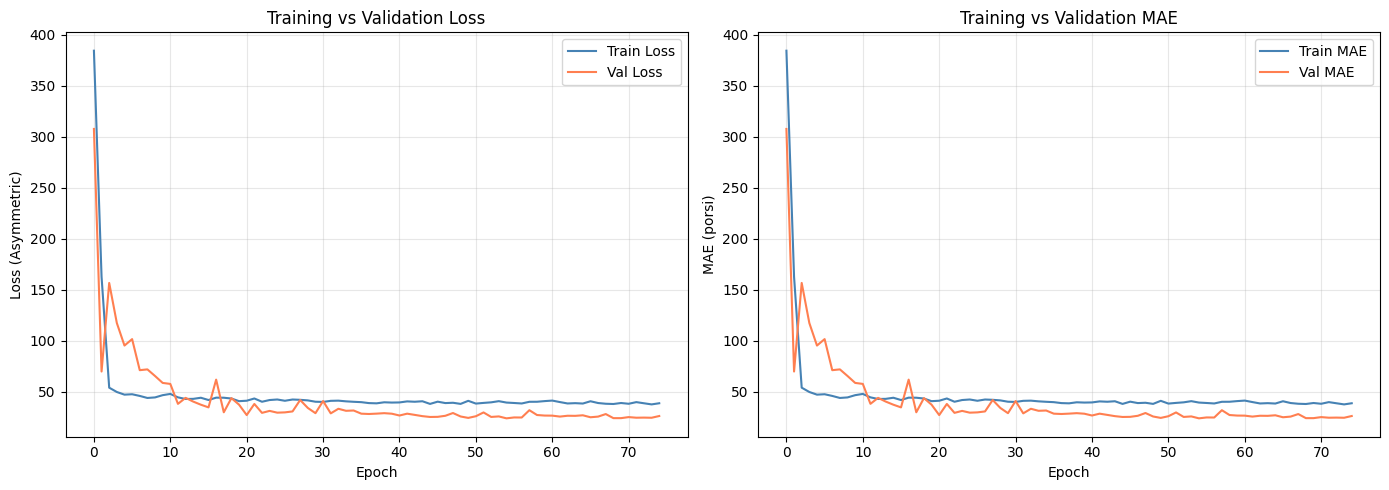

✅ Grafik disimpan: training_history.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Loss
axes[0].plot(history.history['loss'], label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='coral')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (Asymmetric)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot MAE
axes[1].plot(history.history['mae'], label='Train MAE', color='steelblue')
axes[1].plot(history.history['val_mae'], label='Val MAE', color='coral')
axes[1].set_title('Training vs Validation MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (porsi)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik disimpan: training_history.png')

## STEP 9 — Evaluasi Model di Test Set

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step
HASIL EVALUASI (TEST SET)
  MAE  : 24.30 porsi
  RMSE : 40.88 porsi
  MAPE : 5.87%


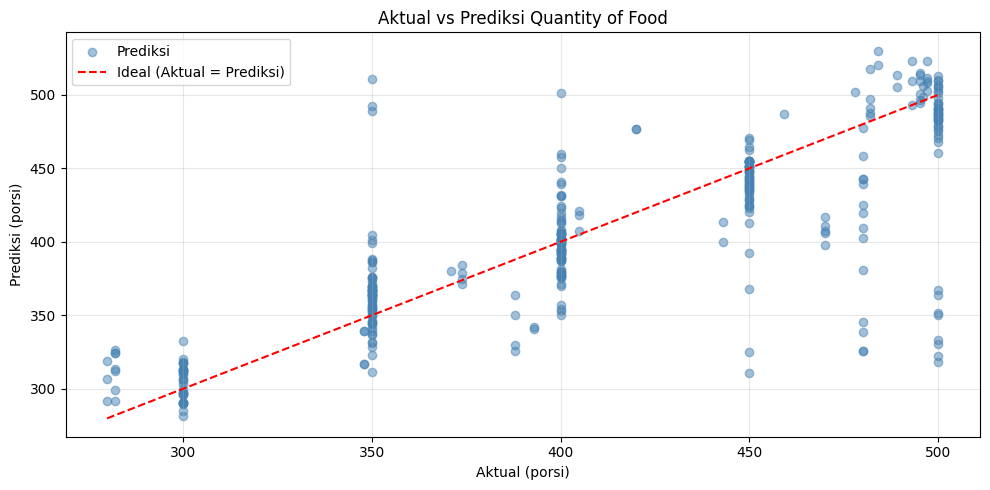

In [10]:
y_pred = model.predict(X_test).flatten()

mae  = np.mean(np.abs(y_test - y_pred))
rmse = np.sqrt(np.mean((y_test - y_pred)**2))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print('HASIL EVALUASI (TEST SET)')
print(f'  MAE  : {mae:.2f} porsi')
print(f'  RMSE : {rmse:.2f} porsi')
print(f'  MAPE : {mape:.2f}%')

# Visualisasi Aktual vs Prediksi
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue', label='Prediksi')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', label='Ideal (Aktual = Prediksi)')
plt.xlabel('Aktual (porsi)')
plt.ylabel('Prediksi (porsi)')
plt.title('Aktual vs Prediksi Quantity of Food')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('actual_vs_pred.png', dpi=150, bbox_inches='tight')
plt.show()

## STEP 10 — Simpan Model & Artifacts

In [11]:
import json
import pickle

model.save('food_waste_model.keras')

artifacts = {
    'feature_cols': categorical_cols + ['Number of Guests', 'Wastage Food Amount'],
    'label_encoders': {col: list(le.classes_) for col, le in encoders.items()}
}
with open('model_artifacts.json', 'w') as f:
    json.dump(artifacts, f, indent=2)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('Model dan artifacts disimpan!')



Model dan artifacts disimpan!


## STEP 11 — Inference Sederhana

Simulasi model dipakai untuk prediksi stok nyata.

Parameters:
- type_of_food        : 'Meat' / 'Vegetables' / 'Fruits' / 'Baked Goods' / 'Dairy Products'
- num_guests          : int (jumlah tamu)
- event_type          : 'Birthday' / 'Corporate' / 'Social Gathering' / 'Wedding'
- storage_conditions  : 'Refrigerated' / 'Room Temperature'
- seasonality         : 'All Seasons' / 'Summer' / 'Winter'
- preparation_method  : 'Buffet' / 'Finger Food' / 'Sit-down Dinner'
- wastage_food_amount : int (estimasi waste historis)

Returns:
- predicted_qty  : int   → stok optimal yang disarankan (porsi)
- waste_ratio    : float → persentase waste terhadap stok prediksi
- recommendation : str   → kategori rekomendasi
- detail         : str   → penjelasan lengkap untuk user

In [14]:
import json
import pickle
import pandas as pd

with open('model_artifacts.json', 'r') as f:
    artifacts = json.load(f)
loaded_encoders = artifacts['label_encoders']

with open('scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

def predict_optimal_stock(type_of_food, num_guests, event_type,
                           storage_conditions, seasonality,
                           preparation_method, wastage_food_amount):

    input_data = {
        'Type of Food': type_of_food,
        'Number of Guests': num_guests,
        'Event Type': event_type,
        'Storage Conditions': storage_conditions,
        'Seasonality': seasonality,
        'Preparation Method': preparation_method,
        'Wastage Food Amount': wastage_food_amount
    }

    # Label encoding
    for col in encoders.keys():
        if input_data[col] in encoders[col].classes_:
            input_data[col] = list(encoders[col].classes_).index(input_data[col])
        else:
            input_data[col] = 0

    input_df = pd.DataFrame([input_data])

    # HARUS HARDCODE URUTAN KOLOM AGAR SCALER TIDAK ERROR
    correct_cols = [
        'Type of Food', 'Number of Guests', 'Event Type',
        'Storage Conditions', 'Seasonality', 'Preparation Method', 'Wastage Food Amount'
    ]
    input_df = input_df[correct_cols]

    # Lakukan scaling
    input_scaled = scaler.transform(input_df)
    predicted = model.predict(input_scaled, verbose=0)[0][0]
    predicted_qty = max(0, round(predicted))

    waste_ratio = (wastage_food_amount / predicted_qty) * 100 if predicted_qty > 0 else 0

    if waste_ratio > 15:
        recommendation = 'Waste ratio TINGGI — pertimbangkan kurangi order'
        detail = (f'Dari {predicted_qty} porsi yang disiapkan, sekitar {wastage_food_amount} porsi '
                  f'({waste_ratio:.1f}%) diprediksi terbuang. '
                  f'Coba kurangi stok atau ubah metode penyajian.')
    elif waste_ratio < 5:
        recommendation = 'Waste ratio RENDAH — stok sudah sangat efisien'
        detail = (f'Dari {predicted_qty} porsi yang disiapkan, hanya {wastage_food_amount} porsi '
                  f'({waste_ratio:.1f}%) yang diprediksi terbuang. '
                  f'Stok kamu sudah optimal!')
    else:
        recommendation = 'Waste ratio NORMAL — stok sudah efisien'
        detail = (f'Dari {predicted_qty} porsi yang disiapkan, sekitar {wastage_food_amount} porsi '
                  f'({waste_ratio:.1f}%) diprediksi terbuang. '
                  f'Masih dalam batas wajar, bisa tambah buffer 5% jika perlu.')

    return predicted_qty, waste_ratio, recommendation, detail

qty, waste_ratio, rec, detail = predict_optimal_stock(
    type_of_food        = 'Vegetables',
    num_guests          = 450,
    event_type          = 'Birthday',
    storage_conditions  = 'Room Temperature',
    seasonality         = 'Summer',
    preparation_method  = 'Buffet',
    wastage_food_amount = 50
)

print('HASIL PREDIKSI')
print(f'Stok Optimal : {qty} porsi')
print(f'Waste Ratio  : {waste_ratio:.1f}%')
print(f'Rekomendasi  : {rec}')
print(f'Detail       : {detail}')

HASIL PREDIKSI
Stok Optimal : 516 porsi
Waste Ratio  : 9.7%
Rekomendasi  : Waste ratio NORMAL — stok sudah efisien
Detail       : Dari 516 porsi yang disiapkan, sekitar 50 porsi (9.7%) diprediksi terbuang. Masih dalam batas wajar, bisa tambah buffer 5% jika perlu.


In [15]:
# Contoh beberapa skenario sekaligus
print('MULTI-SKENARIO PREDIKSI')

skenarios = [
    ('Vegetables',    450, 'Birthday',         'Room Temperature', 'Summer',      'Buffet',           50),
    ('Meat',          300, 'Wedding',           'Refrigerated',     'Summer',      'Buffet',           25),
    ('Baked Goods',   210, 'Corporate',         'Room Temperature', 'Winter',      'Finger Food',      15),
    ('Dairy Products',350, 'Social Gathering',  'Refrigerated',     'All Seasons', 'Sit-down Dinner',  60),
]
labels = ['Skenario 1', 'Skenario 2', 'Skenario 3', 'Skenario 4']

for label, (tf_, ng, et, sc, se, pm, wfa) in zip(labels, skenarios):
    qty, ratio, rec, detail = predict_optimal_stock(tf_, ng, et, sc, se, pm, wfa)
    print(f'\n🔹 {label}')
    print(f'   Input       : {ng} tamu | {tf_} | {et} | {pm} | waste historis {wfa}')
    print(f'   Stok Optimal: {qty} porsi')
    print(f'   Waste Ratio : {ratio:.1f}%')
    print(f'   Rekomendasi : {rec}')
    print(f'   Detail      : {detail}')

MULTI-SKENARIO PREDIKSI

🔹 Skenario 1
   Input       : 450 tamu | Vegetables | Birthday | Buffet | waste historis 50
   Stok Optimal: 516 porsi
   Waste Ratio : 9.7%
   Rekomendasi : Waste ratio NORMAL — stok sudah efisien
   Detail      : Dari 516 porsi yang disiapkan, sekitar 50 porsi (9.7%) diprediksi terbuang. Masih dalam batas wajar, bisa tambah buffer 5% jika perlu.

🔹 Skenario 2
   Input       : 300 tamu | Meat | Wedding | Buffet | waste historis 25
   Stok Optimal: 389 porsi
   Waste Ratio : 6.4%
   Rekomendasi : Waste ratio NORMAL — stok sudah efisien
   Detail      : Dari 389 porsi yang disiapkan, sekitar 25 porsi (6.4%) diprediksi terbuang. Masih dalam batas wajar, bisa tambah buffer 5% jika perlu.

🔹 Skenario 3
   Input       : 210 tamu | Baked Goods | Corporate | Finger Food | waste historis 15
   Stok Optimal: 288 porsi
   Waste Ratio : 5.2%
   Rekomendasi : Waste ratio NORMAL — stok sudah efisien
   Detail      : Dari 288 porsi yang disiapkan, sekitar 15 porsi (5.2%) dip

## CEK MAE DAN AKURASI

In [18]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# 1. Mendapatkan Prediksi dari Test Set
# Di notebook ini, model langsung mengeluarkan output porsi asli
y_pred = model.predict(X_test, verbose=0).flatten()

# Pastikan y_true berbentuk numpy array
y_true = y_test.values if hasattr(y_test, 'values') else np.array(y_test)

# 2. Hitung Akurasi (Berdasarkan persentase keakuratan tebakan stok)
mape = mean_absolute_percentage_error(y_true, y_pred)
akurasi = (1 - mape) * 100

# 3. Hitung MAE Normalized / Waste Ratio
# Dapatkan data input X_test mentah yang belum di-scaling
X_test_mentah = scaler.inverse_transform(X_test)

# Ambil kolom Wastage Food Amount (kolom paling terakhir, indeks ke-6)
wastage_historis = X_test_mentah[:, 6]

# Prediksi rasio waste vs aktual rasio waste
true_ratio = wastage_historis / y_true
pred_ratio = wastage_historis / y_pred

mae_ratio = mean_absolute_error(true_ratio, pred_ratio)

print(f"Akurasi Model : {akurasi:.2f}%")
print(f"MAE Rasio     : {mae_ratio:.4f}")


Akurasi Model : 94.13%
MAE Rasio     : 0.0040


##Download .keras dan .json


In [19]:
from google.colab import files

files.download('food_waste_model.keras')
files.download('model_artifacts.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>